## Task 3 — Well-resourced score for Sydney - Blacktown

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Load SA2 POI count file of Sydney - Blacktown

try:
    poi_count_by_sa2 = pd.read_csv("blacktown_poi_count_by_sa2.csv", encoding="utf-8-sig")
except UnicodeDecodeError:
    poi_count_by_sa2 = pd.read_csv("blacktown_poi_count_by_sa2.csv", encoding="latin1")

print("POI count table shape:", poi_count_by_sa2.shape)
display(poi_count_by_sa2.head())

POI count table shape: (24, 3)


,SA2_NAME,SA2_CODE,poi_count
0,Blacktown (East) - Kings Park,116011303,196
1,Lalor Park - Kings Langley,116011307,156
2,Mount Druitt - Whalan,116031317,139
3,Riverstone,116021630,118
4,Bidwill - Hebersham - Emerton,116031313,117


In [18]:
# Standardise POI count column names

poi_count_by_sa2 = poi_count_by_sa2.rename(columns={
    "source_sa2_code": "sa2_code",
    "source_sa2_name": "sa2_name",
    "source_sa4_name": "sa4_name",
    "SA2_CODE21": "sa2_code",
    "SA2_NAME21": "sa2_name",
    "SA4_NAME21": "sa4_name",
    "sa2_code21": "sa2_code",
    "sa2_name21": "sa2_name",
    "sa4_name21": "sa4_name",
    "SA2_CODE": "sa2_code",
    "SA2_NAME": "sa2_name",
    "poi count": "poi_count",
    "POI Count": "poi_count",
    "count": "poi_count",
    "Count": "poi_count"
})

# Add SA4 name if it is not already included
if "sa4_name" not in poi_count_by_sa2.columns:
    poi_count_by_sa2["sa4_name"] = "Sydney - Blacktown"

score_df = poi_count_by_sa2[
    ["sa2_code", "sa2_name", "sa4_name", "poi_count"]
].copy()

score_df["sa2_code"] = (
    score_df["sa2_code"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)

score_df["sa2_name"] = score_df["sa2_name"].astype(str).str.strip()
score_df["sa4_name"] = score_df["sa4_name"].astype(str).str.strip()

score_df["poi_count"] = pd.to_numeric(
    score_df["poi_count"],
    errors="coerce"
).fillna(0).astype(int)

display(score_df.head())

,sa2_code,sa2_name,sa4_name,poi_count
0,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown,196
1,116011307,Lalor Park - Kings Langley,Sydney - Blacktown,156
2,116031317,Mount Druitt - Whalan,Sydney - Blacktown,139
3,116021630,Riverstone,Sydney - Blacktown,118
4,116031313,Bidwill - Hebersham - Emerton,Sydney - Blacktown,117


In [19]:
# Check POI count data before scoring

print("Number of SA2 regions:", len(score_df))
print("Minimum POI count:", score_df["poi_count"].min())
print("Maximum POI count:", score_df["poi_count"].max())

display(
    score_df.sort_values(
        by="poi_count",
        ascending=False
    ).head()
)

Number of SA2 regions: 24
Minimum POI count: 2
Maximum POI count: 196


,sa2_code,sa2_name,sa4_name,poi_count
0,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown,196
1,116011307,Lalor Park - Kings Langley,Sydney - Blacktown,156
2,116031317,Mount Druitt - Whalan,Sydney - Blacktown,139
3,116021630,Riverstone,Sydney - Blacktown,118
4,116031313,Bidwill - Hebersham - Emerton,Sydney - Blacktown,117


In [20]:
# Calculate zPOI
# zPOI = (poi_count - mean poi_count) / standard deviation of poi_count

poi_mean = score_df["poi_count"].mean()
poi_std = score_df["poi_count"].std()

print("Mean POI count:", round(poi_mean, 2))
print("Standard deviation of POI count:", round(poi_std, 2))

score_df["zPOI"] = (
    (score_df["poi_count"] - poi_mean) / poi_std
)

display(score_df.head())

Mean POI count: 67.79
Standard deviation of POI count: 49.9


,sa2_code,sa2_name,sa4_name,poi_count,zPOI
0,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown,196,2.569356
1,116011307,Lalor Park - Kings Langley,Sydney - Blacktown,156,1.767737
2,116031317,Mount Druitt - Whalan,Sydney - Blacktown,139,1.427049
3,116021630,Riverstone,Sydney - Blacktown,118,1.006199
4,116031313,Bidwill - Hebersham - Emerton,Sydney - Blacktown,117,0.986159


In [21]:
# Calculate final score using sigmoid function
# Score = S(zPOI) = 1 / (1 + exp(-zPOI))

score_df["score"] = 1 / (1 + np.exp(-score_df["zPOI"]))

display(score_df.head())

,sa2_code,sa2_name,sa4_name,poi_count,zPOI,score
0,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown,196,2.569356,0.928863
1,116011307,Lalor Park - Kings Langley,Sydney - Blacktown,156,1.767737,0.854176
2,116031317,Mount Druitt - Whalan,Sydney - Blacktown,139,1.427049,0.806441
3,116021630,Riverstone,Sydney - Blacktown,118,1.006199,0.732276
4,116031313,Bidwill - Hebersham - Emerton,Sydney - Blacktown,117,0.986159,0.728328


In [22]:
# Sort the final result by score

final_score = score_df[
    [
        "sa2_code",
        "sa2_name",
        "sa4_name",
        "poi_count",
        "zPOI",
        "score"
    ]
].copy()

final_score["zPOI"] = final_score["zPOI"].round(6)
final_score["score"] = final_score["score"].round(6)

final_score = final_score.sort_values(
    by="score",
    ascending=False
).reset_index(drop=True)

display(final_score)

,sa2_code,sa2_name,sa4_name,poi_count,zPOI,score
0,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown,196,2.569356,0.928863
1,116011307,Lalor Park - Kings Langley,Sydney - Blacktown,156,1.767737,0.854176
2,116031317,Mount Druitt - Whalan,Sydney - Blacktown,139,1.427049,0.806441
3,116021630,Riverstone,Sydney - Blacktown,118,1.006199,0.732276
4,116031313,Bidwill - Hebersham - Emerton,Sydney - Blacktown,117,0.986159,0.728328
5,116031318,Prospect Reservoir,Sydney - Blacktown,99,0.625430,0.651452
6,116011626,Seven Hills - Prospect,Sydney - Blacktown,92,0.485147,0.618962
7,116011304,Blacktown (North) - Marayong,Sydney - Blacktown,83,0.304782,0.575611
8,116031319,Rooty Hill - Minchinbury,Sydney - Blacktown,67,-0.015865,0.496034
9,116011306,Doonside - Woodcroft,Sydney - Blacktown,66,-0.035906,0.491025


In [23]:
# Save the Task 3 result

final_score.to_csv(
    "task3_sydney_blacktown_scores.csv",
    index=False
)

print("Saved task3_sydney_blacktown_scores.csv")

Saved task3_sydney_blacktown_scores.csv


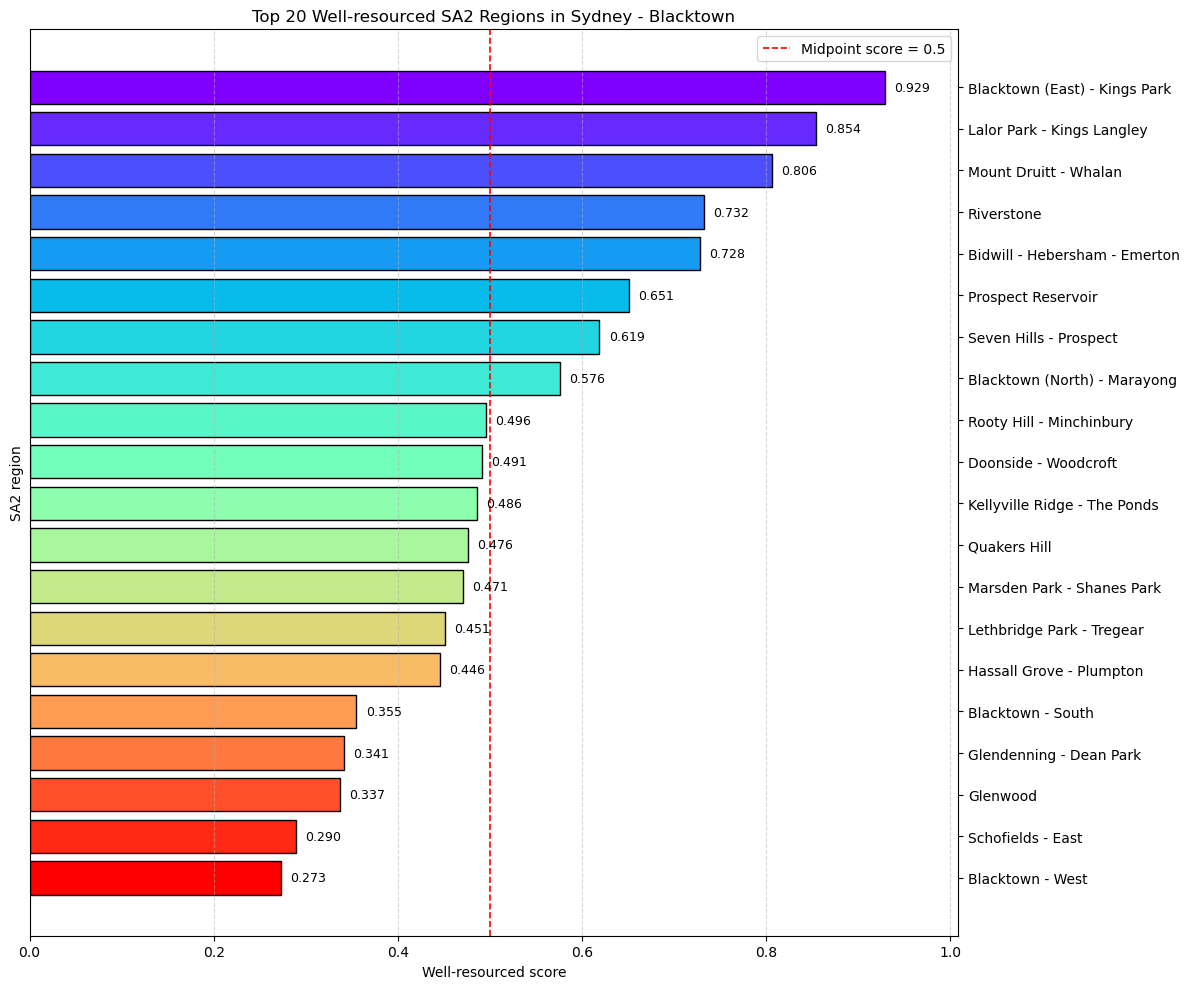

In [24]:
# Figure 1. The Top 20 SA2 regions by well-resourced score

palette = plt.cm.rainbow(np.linspace(0, 1, 20))

top20_score = final_score.head(20).copy()

plt.figure(figsize=(12, 10))

bars = plt.barh(
    top20_score["sa2_name"],
    top20_score["score"],
    color=palette[:len(top20_score)],
    edgecolor="black"
)

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Well-resourced score")
plt.ylabel("SA2 region")
plt.title("Top 20 Well-resourced SA2 Regions in Sydney - Blacktown")

# Put SA2 names on the right side, while keeping the y-axis label on the left
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
ax.tick_params(axis="y", labelleft=False, labelright=True)

plt.gca().invert_yaxis()

# Add midpoint line
plt.axvline(x=0.5, color="red", linestyle="--", linewidth=1.2, label="Midpoint score = 0.5")

plt.xlim(0, top20_score["score"].max() + 0.08)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

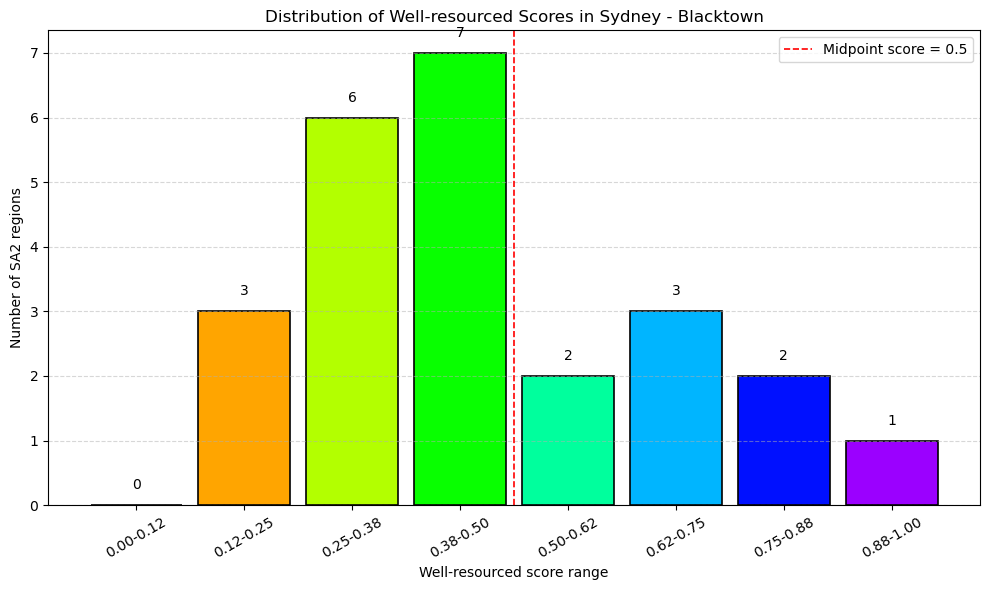

In [25]:
# Figure 2. The distribution of well-resourced scores

palette = plt.cm.hsv(np.linspace(0, 1, 10))

score_values = final_score["score"]

# Create score bins from 0 to 1
counts, bins = np.histogram(score_values, bins=np.linspace(0, 1, 9))
bin_centres = (bins[:-1] + bins[1:]) / 2
bin_widths = np.diff(bins)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    bin_centres,
    counts,
    width=bin_widths * 0.85,
    color=palette[:len(counts)],
    edgecolor="black",
    linewidth=1.2
)

# Add frequency labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Well-resourced score range")
plt.ylabel("Number of SA2 regions")
plt.title("Distribution of Well-resourced Scores in Sydney - Blacktown")

plt.xticks(
    bin_centres,
    [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins)-1)],
    rotation=30
)

plt.axvline(x=0.5, color="red", linestyle="--", linewidth=1.2, label="Midpoint score = 0.5")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# Summary values for Task 3

top_sa2 = final_score.iloc[0]
bottom_sa2 = final_score.iloc[-1]

mean_score = final_score["score"].mean()
median_score = final_score["score"].median()

mean_poi = final_score["poi_count"].mean()
max_poi = final_score["poi_count"].max()
min_poi = final_score["poi_count"].min()

print("Summary values for Sydney - Blacktown")
print("Number of SA2 regions:", len(final_score))
print("Highest-scoring SA2:", top_sa2["sa2_name"])
print("Highest score:", round(top_sa2["score"], 3))
print("Highest POI count:", top_sa2["poi_count"])
print("Lowest-scoring SA2:", bottom_sa2["sa2_name"])
print("Lowest score:", round(bottom_sa2["score"], 3))
print("Lowest POI count:", bottom_sa2["poi_count"])
print("Mean score:", round(mean_score, 3))
print("Median score:", round(median_score, 3))
print("Minimum POI count:", min_poi)
print("Maximum POI count:", max_poi)
print("Mean POI count:", round(mean_poi, 2))

Summary values for Sydney - Blacktown
Number of SA2 regions: 24
Highest-scoring SA2: Blacktown (East) - Kings Park
Highest score: 0.929
Highest POI count: 196
Lowest-scoring SA2: Acacia Gardens
Lowest score: 0.211
Lowest POI count: 2
Mean score: 0.49
Median score: 0.474
Minimum POI count: 2
Maximum POI count: 196
Mean POI count: 67.79


### Task 3 summary for Sydney - Blacktown

1. A total of **24 SA2 regions** in Sydney - Blacktown were scored using POI count as the resource indicator.

2. The highest-scoring SA2 was **Blacktown (East) - Kings Park**, with a well-resourced score of **0.929** and **196 POIs**, indicating the strongest resource availability in this SA4.

3. The lowest-scoring SA2 was **Acacia Gardens**, with a well-resourced score of **0.211** and **2 POIs**, indicating the weakest resource availability in this SA4.

4. The average well-resourced score was **0.490**, while the median score was **0.474**. POI counts ranged from **2 to 196**, with an average of **67.79 POIs per SA2**.

5. The Top 20 chart highlights the highest-scoring SA2 regions, while the score distribution chart shows how scores are spread across Sydney - Blacktown. The midpoint line at **score = 0.5** helps distinguish SA2 regions above and below the average-resource level after z-score standardisation and sigmoid transformation.

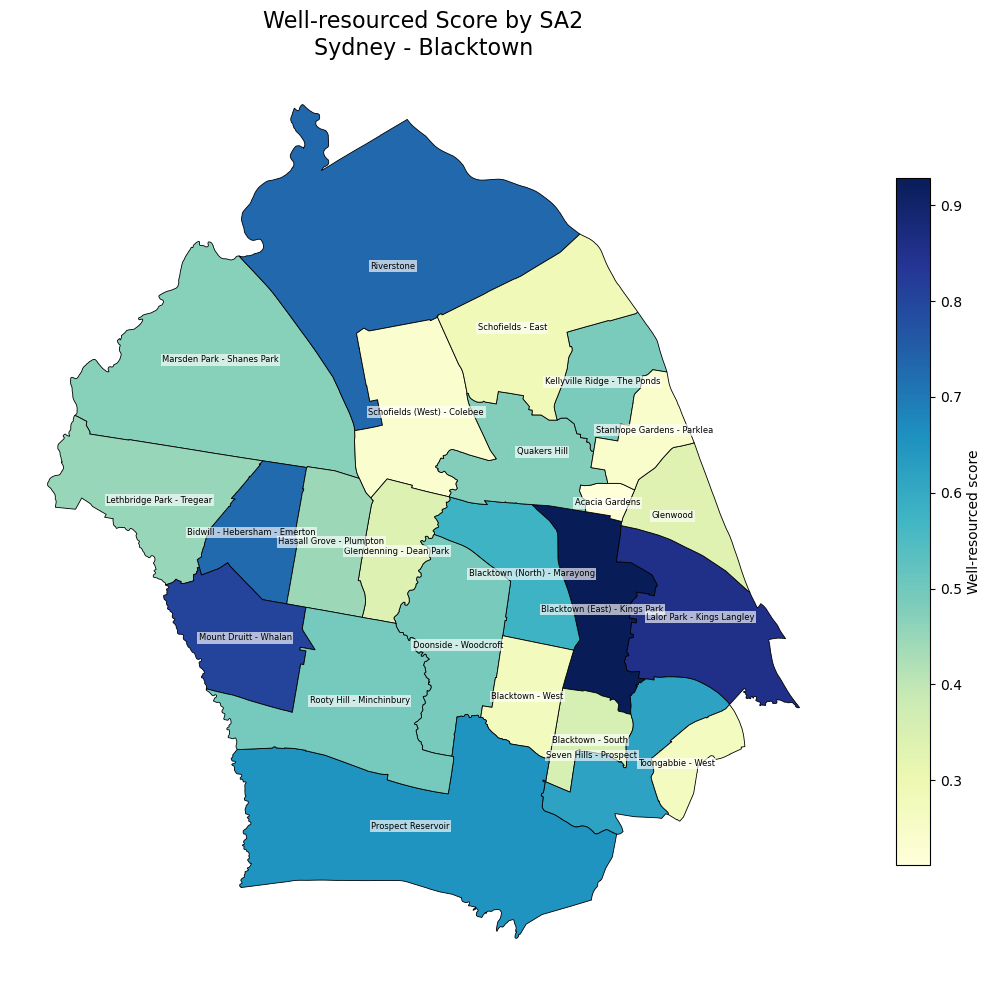

In [27]:
# Figure 3. Map of well-resourced score by SA2
# This uses the GeoJSON boundary file generated from Task 2.

import geopandas as gpd
import matplotlib.pyplot as plt

# Load Sydney - Parramatta SA2 boundary file
sa2_map = gpd.read_file("blacktown_sa2_boundaries.geojson")

# Standardise column names if needed
sa2_map = sa2_map.rename(columns={
    "SA2_CODE21": "sa2_code",
    "SA2_NAME21": "sa2_name",
    "SA4_NAME21": "sa4_name",
    "source_sa2_code": "sa2_code",
    "source_sa2_name": "sa2_name",
    "source_sa4_name": "sa4_name"
})

# Clean SA2 code format
sa2_map["sa2_code"] = (
    sa2_map["sa2_code"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)

final_score["sa2_code"] = (
    final_score["sa2_code"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)

# Merge score table with geometry
score_map = sa2_map.merge(
    final_score[["sa2_code", "poi_count", "zPOI", "score"]],
    on="sa2_code",
    how="left"
)

# Plot map
fig, ax = plt.subplots(figsize=(12, 10))

score_map.plot(
    column="score",
    ax=ax,
    cmap="YlGnBu",
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    legend_kwds={
        "label": "Well-resourced score",
        "shrink": 0.75
    }
)

# Add SA2 names on the map
for idx, row in score_map.iterrows():
    point = row["geometry"].representative_point()
    ax.text(
        point.x,
        point.y,
        row["sa2_name"],
        fontsize=6,
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.65,
            edgecolor="none",
            pad=1
        )
    )

ax.set_title(
    "Well-resourced Score by SA2\nSydney - Blacktown",
    fontsize=16
)

ax.axis("off")
plt.tight_layout()
plt.show()